In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
start = '2010-01-01'
end = '2019-12-31'

df = yf.download('AAPL', start=start, end=end)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.454505,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.465663,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.362819,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.351058,477131200
2010-01-08,7.510714,7.571429,7.466429,7.570714,6.393280,447610800


In [4]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-12-23,70.132500,71.062500,70.092499,71.000000,68.908981,98572000
2019-12-24,71.172501,71.222504,70.730003,71.067497,68.974495,48478800
2019-12-26,71.205002,72.495003,71.175003,72.477501,70.342972,93121200
2019-12-27,72.779999,73.492500,72.029999,72.449997,70.316277,146266000
2019-12-30,72.364998,73.172501,71.305000,72.879997,70.733627,144114400


In [5]:
df = df.reset_index()

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.454505,493729600
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.465663,601904800
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.362819,552160000
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.351058,477131200
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.393280,447610800


In [7]:
df = df.drop(['Date', 'Adj Close'], axis=1)

In [8]:
df.head()

,Open,High,Low,Close,Volume
0,7.622500,7.660714,7.585000,7.643214,493729600
1,7.664286,7.699643,7.616071,7.656429,601904800
2,7.656429,7.686786,7.526786,7.534643,552160000
3,7.562500,7.571429,7.466071,7.520714,477131200
4,7.510714,7.571429,7.466429,7.570714,447610800


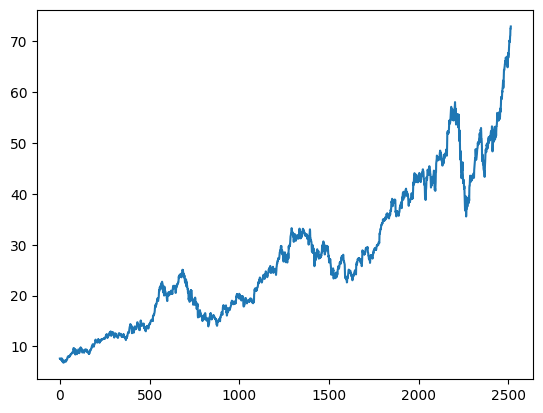

In [9]:
plt.plot(df.Close)

In [10]:
df

,Open,High,Low,Close,Volume
0,7.622500,7.660714,7.585000,7.643214,493729600
1,7.664286,7.699643,7.616071,7.656429,601904800
2,7.656429,7.686786,7.526786,7.534643,552160000
3,7.562500,7.571429,7.466071,7.520714,477131200
4,7.510714,7.571429,7.466429,7.570714,447610800
...,...,...,...,...,...
2510,70.132500,71.062500,70.092499,71.000000,98572000
2511,71.172501,71.222504,70.730003,71.067497,48478800
2512,71.205002,72.495003,71.175003,72.477501,93121200
2513,72.779999,73.492500,72.029999,72.449997,146266000


In [11]:
ma100 = df.Close.rolling(100).mean()
ma100

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,59.201075
2511,59.401700
2512,59.643125
2513,59.875125


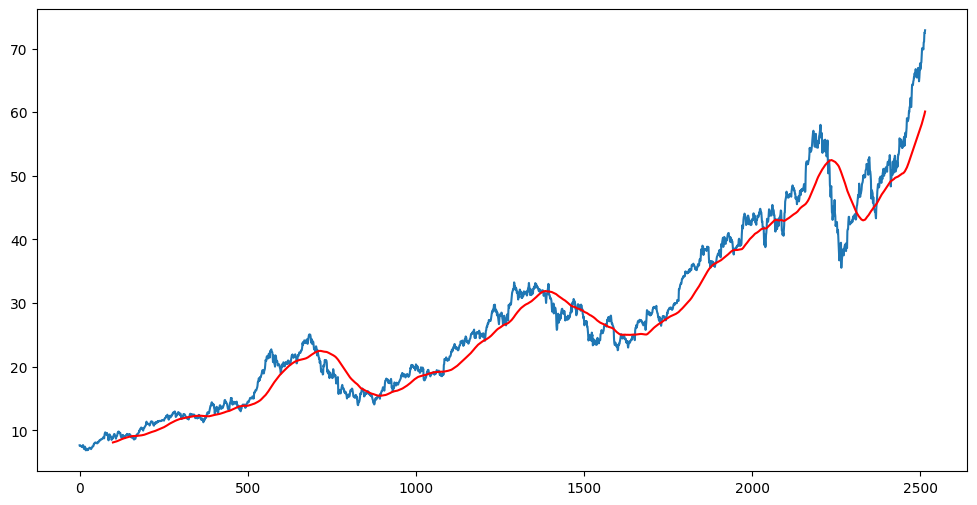

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

In [13]:
ma200 = df.Close.rolling(200).mean()
ma200

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,54.132313
2511,54.261513
2512,54.396763
2513,54.529350


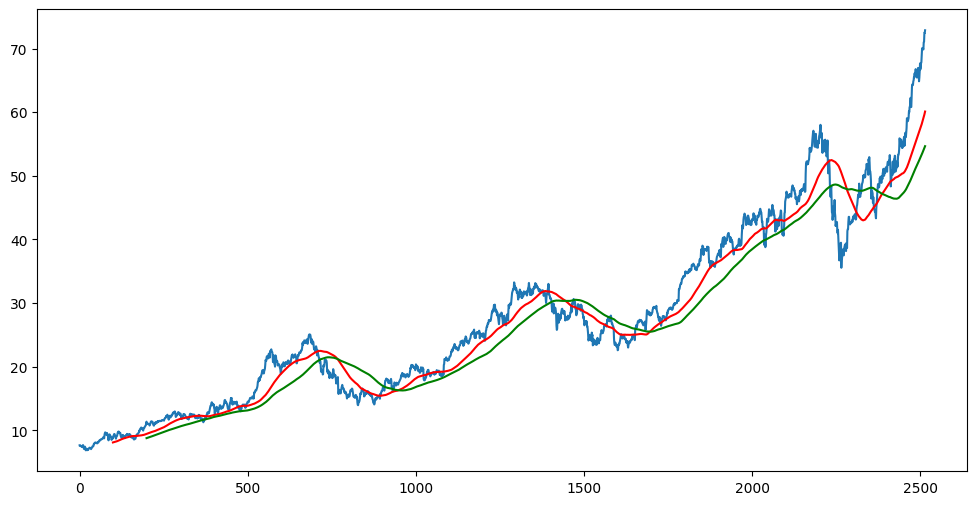

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [15]:
df.shape

(2515, 5)

In [16]:
#Spliting Data into Training and Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

print(data_training.shape)
print(data_testing.shape)

(1760, 1)
(755, 1)


In [17]:
data_training.head()

,Close
0,7.643214
1,7.656429
2,7.534643
3,7.520714
4,7.570714


In [18]:
data_testing.head()

,Close
1760,29.182501
1761,28.955000
1762,29.037500
1763,29.004999
1764,29.152500


In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [20]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02971782],
       [0.03021854],
       [0.02560389],
       ...,
       [0.84388656],
       [0.85089656],
       [0.84616011]])

In [21]:
data_training_array.shape

(1760, 1)

In [22]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [23]:
x_train.shape

(1660, 100, 1)

In [24]:
# Model Training

In [25]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [26]:
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))



model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))



model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))




model.add(LSTM(units=50, activation='relu'))
model.add(Dropout(0.5))



model.add(Dense(units=1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          26,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 108,411 (423.48 KB)

 Trainable params: 108,411 (423.48 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - loss: 0.1380
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0220
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0173
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0154
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0136
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0134
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0127
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0123
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0130
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0099
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0109
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0108
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0092
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0097
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0100
Ep

In [30]:
model.save('analysis_model.h5')

In [32]:
from keras.models import load_model


In [33]:
# Load the saved model
model = load_model('/content/drive/MyDrive/stock_market_analysis/analysis_model.h5')

In [34]:
data_testing.head()

,Close
1760,29.182501
1761,28.955000
1762,29.037500
1763,29.004999
1764,29.152500


In [35]:
past_100_days = data_training.tail(100)

In [36]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [37]:
final_df.head()

,Close
0,27.092501
1,27.202499
2,27.000000
3,26.982500
4,27.045000


In [38]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.02781467],
       [0.03015022],
       [0.02585064],
       [0.02547908],
       [0.02680611],
       [0.03370671],
       [0.03317586],
       [0.03232658],
       [0.03158344],
       [0.03306972],
       [0.02855781],
       [0.03036255],
       [0.02600988],
       [0.02356814],
       [0.02022403],
       [0.01958704],
       [0.01523437],
       [0.01576518],
       [0.01910933],
       [0.02441747],
       [0.02425819],
       [0.02776158],
       [0.01268645],
       [0.        ],
       [0.01226183],
       [0.02558522],
       [0.04586231],
       [0.06603324],
       [0.06258295],
       [0.05547006],
       [0.05541697],
       [0.05531082],
       [0.06099053],
       [0.05085197],
       [0.05175434],
       [0.05286905],
       [0.05743405],
       [0.04803866],
       [0.05265676],
       [0.04984341],
       [0.05239133],
       [0.05265676],
       [0.05711557],
       [0.05801795],
       [0.06858117],
       [0.0699082 ],
       [0.07542863],
       [0.073

In [39]:
input_data.shape

(855, 1)

In [40]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [41]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(755, 100, 1)
(755,)


In [42]:
# Making Predictions

y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step


In [43]:
y_predicted.shape

(755, 1)

In [44]:
y_predicted

array([[0.10857838],
       [0.10875407],
       [0.1089429 ],
       [0.10914198],
       [0.10934776],
       [0.10955632],
       [0.10976407],
       [0.10997143],
       [0.11018333],
       [0.11040524],
       [0.11064342],
       [0.11089936],
       [0.11116961],
       [0.11145648],
       [0.11175933],
       [0.11207604],
       [0.11240402],
       [0.11274037],
       [0.11308107],
       [0.11343697],
       [0.11381558],
       [0.11422181],
       [0.11465308],
       [0.11511213],
       [0.11565948],
       [0.11633709],
       [0.11718467],
       [0.11823615],
       [0.11952251],
       [0.12106711],
       [0.12287644],
       [0.12494081],
       [0.1272563 ],
       [0.12982133],
       [0.13262966],
       [0.1356583 ],
       [0.13888231],
       [0.14227766],
       [0.1458163 ],
       [0.1494585 ],
       [0.15316874],
       [0.15691558],
       [0.1606926 ],
       [0.16449985],
       [0.1683389 ],
       [0.17218736],
       [0.17599806],
       [0.179

In [45]:
scaler.scale_

array([0.02123255])

In [46]:
scale_factor = 1/0.02123255
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

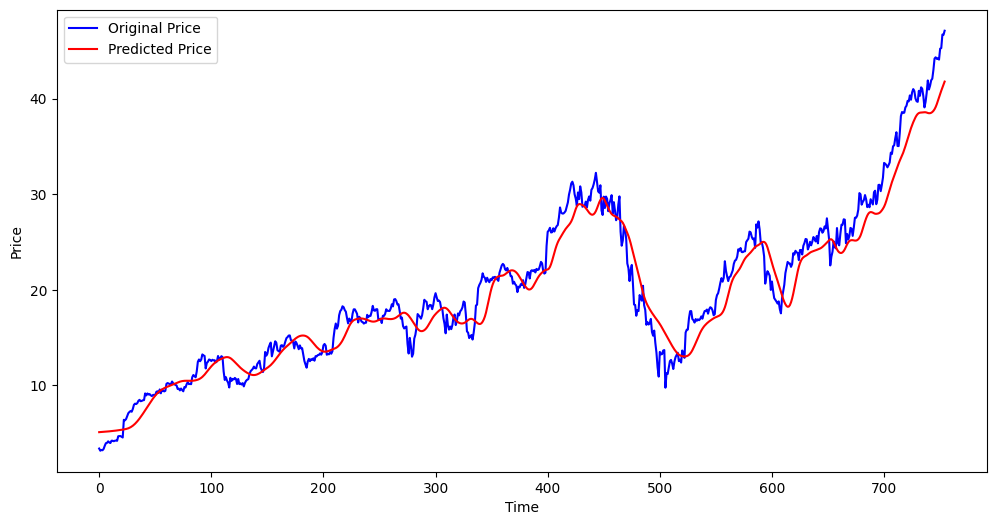

In [47]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [49]:
import numpy as np
from keras.models import load_model
from sklearn.metrics import r2_score

# Load the saved model
model = load_model('/content/drive/MyDrive/stock_market_analysis/analysis_model.h5')

# Prepare your test data (make sure x_test is shaped correctly)
# Assuming x_test is already prepared and contains the input features

# Make predictions
y_pred = model.predict(x_test)

# In case you need to rescale your predictions (if you used MinMaxScaler)
scale_factor = 1 / scaler.scale_[0]  # Assuming scaler was fitted to the training data
y_pred_rescaled = y_pred * scale_factor

# Calculate the R² score
r2 = r2_score(y_test, y_pred_rescaled)

print(f"R² Score: {r2}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
R² Score: 0.9422800616204166
